# Phần 1: Khảo Sát Dữ Liệu (Exploratory Data Analysis — EDA)
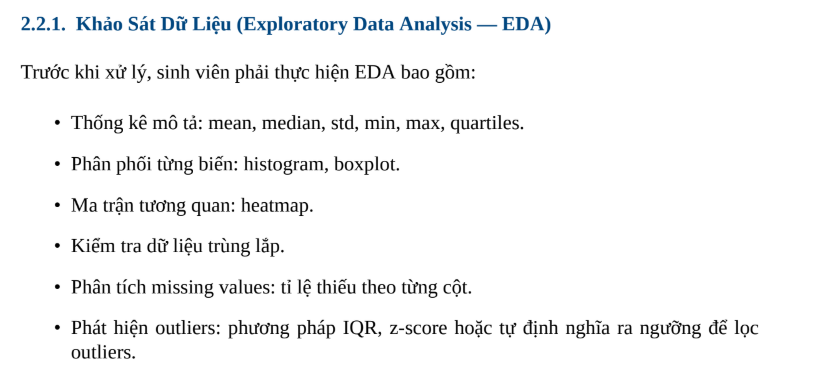

## 1. Thống kê mô tả

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cài đặt style cho đồ thị
sns.set_theme(style="whitegrid")

# Load dữ liệu
df = pd.read_csv('data/Life Expectancy Data.csv')

# Loại bỏ khoảng trắng thừa trong tên cột
df.columns = df.columns.str.strip()

print(f"Kích thước bộ dữ liệu: {df.shape}")

# Thống kê mô tả (mean, median, std, min, max, quartiles)
display(df.describe())

# Xem qua các biến phân loại
display(df.describe(exclude='number'))

Kích thước bộ dữ liệu: (2938, 22)


,Year,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
count,2938.000000,2928.000000,2928.000000,2938.000000,2744.000000,2938.000000,2385.000000,2938.000000,2904.000000,2938.000000,2919.000000,2712.00000,2919.000000,2938.000000,2490.000000,2.286000e+03,2904.000000,2904.000000,2771.000000,2775.000000
mean,2007.518720,69.224932,164.796448,30.303948,4.602861,738.251295,80.940461,2419.592240,38.321247,42.035739,82.550188,5.93819,82.324084,1.742103,7483.158469,1.275338e+07,4.839704,4.870317,0.627551,11.992793
std,4.613841,9.523867,124.292079,117.926501,4.052413,1987.914858,25.070016,11467.272489,20.044034,160.445548,23.428046,2.49832,23.716912,5.077785,14270.169342,6.101210e+07,4.420195,4.508882,0.210904,3.358920
min,2000.000000,36.300000,1.000000,0.000000,0.010000,0.000000,1.000000,0.000000,1.000000,0.000000,3.000000,0.37000,2.000000,0.100000,1.681350,3.400000e+01,0.100000,0.100000,0.000000,0.000000
25%,2004.000000,63.100000,74.000000,0.000000,0.877500,4.685343,77.000000,0.000000,19.300000,0.000000,78.000000,4.26000,78.000000,0.100000,463.935626,1.957932e+05,1.600000,1.500000,0.493000,10.100000
50%,2008.000000,72.100000,144.000000,3.000000,3.755000,64.912906,92.000000,17.000000,43.500000,4.000000,93.000000,5.75500,93.000000,0.100000,1766.947595,1.386542e+06,3.300000,3.300000,0.677000,12.300000
75%,2012.000000,75.700000,228.000000,22.000000,7.702500,441.534144,97.000000,360.250000,56.200000,28.000000,97.000000,7.49250,97.000000,0.800000,5910.806335,7.420359e+06,7.200000,7.200000,0.779000,14.300000
max,2015.000000,89.000000,723.000000,1800.000000,17.870000,19479.911610,99.000000,212183.000000,87.300000,2500.000000,99.000000,17.60000,99.000000,50.600000,119172.741800,1.293859e+09,27.700000,28.600000,0.948000,20.700000


,Country,Status
count,2938,2938
unique,193,2
top,Afghanistan,Developing
freq,16,2426


## 2. Trực quan hóa dữ liệu (Histogram & Boxplot)

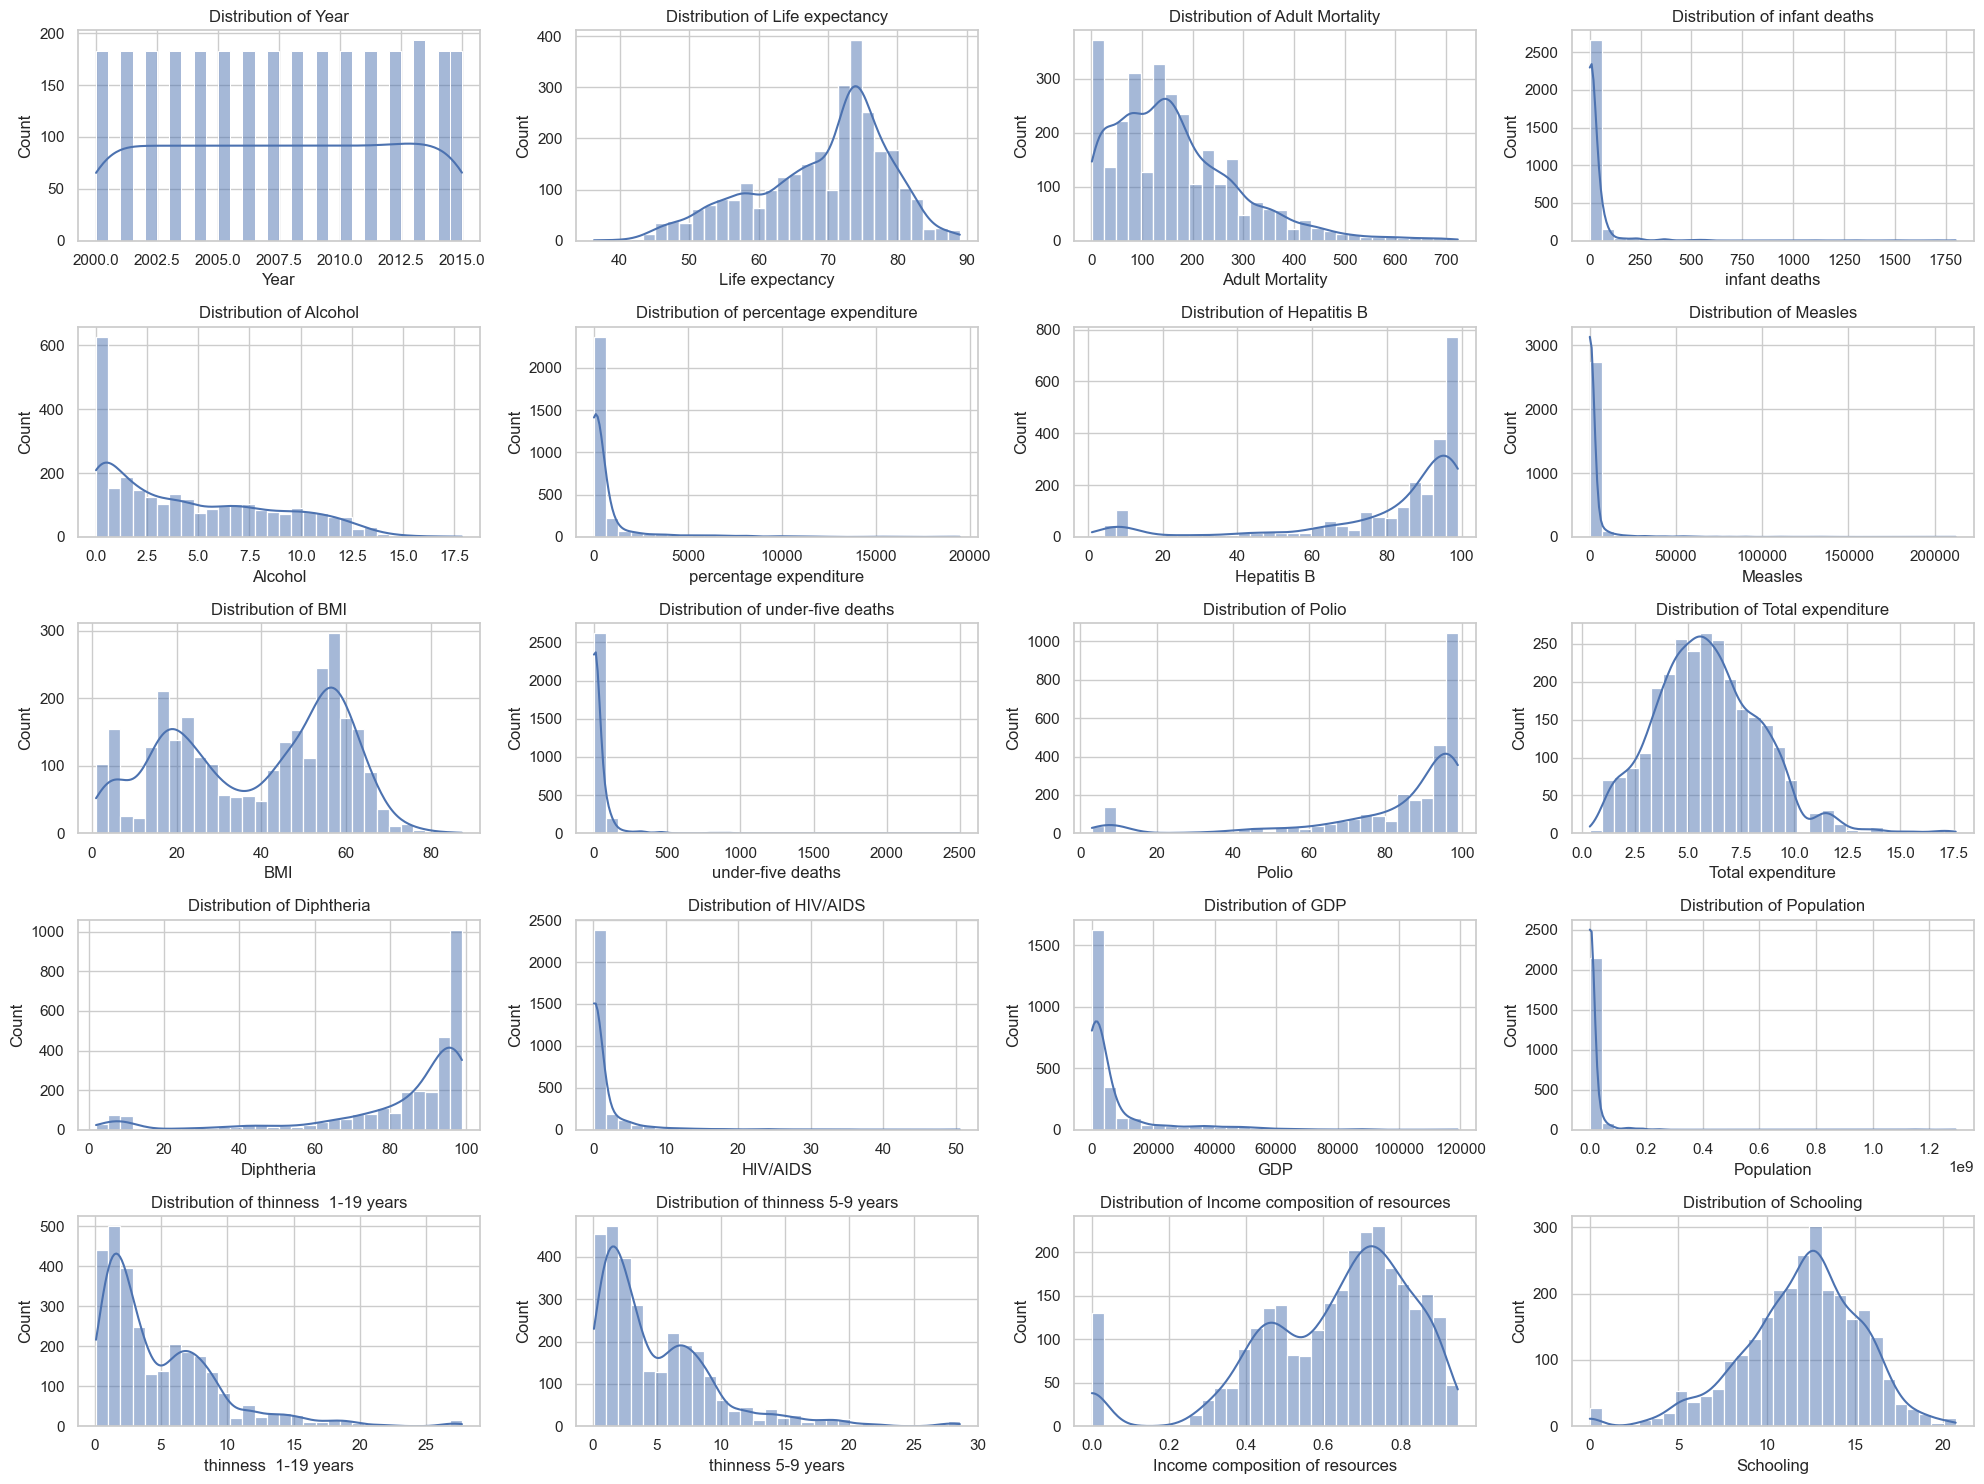

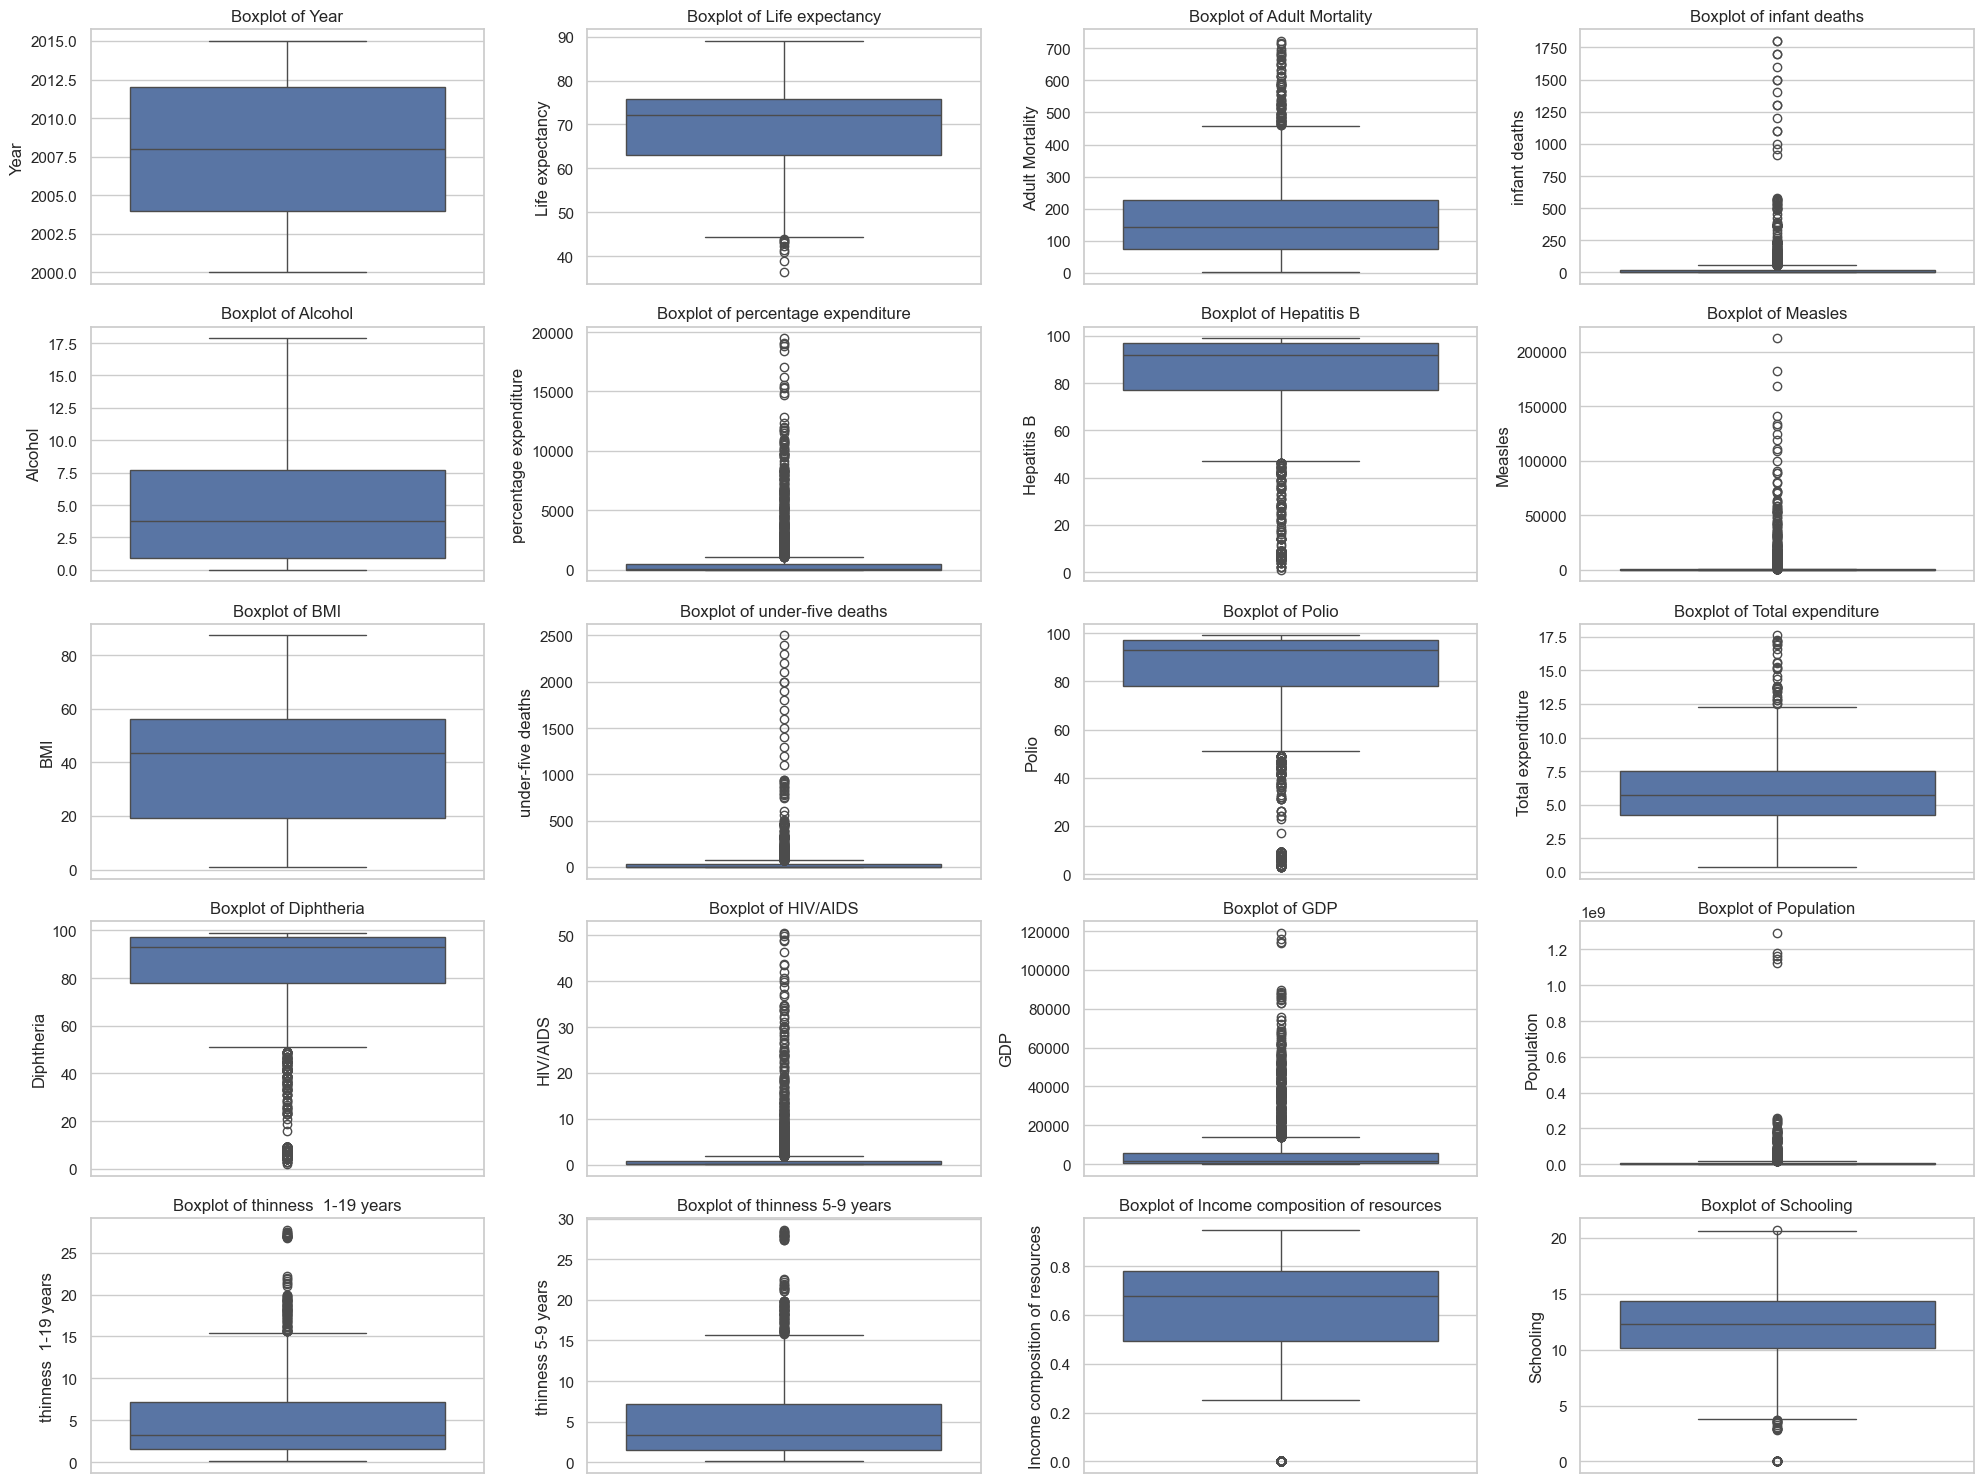

In [5]:
# Tách các biến số (numeric) để vẽ đồ thị
numeric_cols = df.select_dtypes(include=[np.number]).columns

# 2.1 Vẽ Histogram xem phân phối
plt.figure(figsize=(20, 15))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(5, 4, i)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.tight_layout()
plt.show()

# 2.2 Vẽ Boxplot để nhận diện Outliers
plt.figure(figsize=(20, 15))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(5, 4, i)
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')
    plt.tight_layout()
plt.show()

### Nhận xét về Phân phối dữ liệu (Data Distribution)
Thông qua bảng thống kê mô tả và biểu đồ Histogram, ta có thể rút ra một số đặc điểm quan trọng của bộ dữ liệu:
* **Biến mục tiêu (`Life expectancy`):** Phân phối hơi lệch trái (Left-skewed), tập trung chủ yếu ở dải từ 70 đến 75 tuổi. Điều này phản ánh thực tế xu hướng tuổi thọ của con người trên toàn cầu đang ở mức tương đối cao.
* **Các biến kinh tế - xã hội (`GDP`, `Population`, `percentage expenditure`):** Đều bị lệch phải (Right-skewed) rất nghiêm trọng. Hầu hết các quan sát tập trung ở giá trị thấp, kéo theo một cái đuôi dài về phía bên phải. Nó phản ánh sự phân hóa giàu nghèo trên thế giới: đa số là các quốc gia đang phát triển với GDP/Dân số ở mức vừa và thấp, trong khi chỉ có một số ít các siêu cường quốc có mức GDP và dân số khổng lồ.
* **Tác động đến mô hình OLS:** Sự sai lệch mạnh so với phân phối chuẩn của các biến độc lập có thể làm suy yếu các giả định Gauss-Markov (đặc biệt là giả định về phương sai phần dư không đổi - Homoscedasticity). Do đó, ở bước Data Pipeline sắp tới, nhóm cần xem xét áp dụng **phép biến đổi Logarit (Log-transformation)** cho các biến bị lệch phải nặng.

### Nhận xét về Giá trị ngoại lệ (Outliers)
Biểu đồ Boxplot cho thấy sự xuất hiện dày đặc của các giá trị ngoại lệ, cụ thể:
* Các biến như `Measles` (Bệnh sởi), `infant deaths` (Tử vong trẻ sơ sinh), `HIV/AIDS` có số lượng outliers vút lên rất cao so với phần thân của boxplot (phía trên râu trên - upper whisker).
* **Đánh giá bản chất:** Đây phần lớn là các **Outliers tự nhiên (True Outliers)**, phản ánh sự bùng phát dịch bệnh hoặc tình trạng y tế yếu kém ở một số quốc gia/năm cụ thể, chứ không phải do lỗi nhập liệu (Data entry errors).
* **Hướng xử lý cho OLS:** Mô hình OLS cực kỳ nhạy cảm với các điểm ngoại lệ. Các điểm này có thể tạo ra hiệu ứng đòn bẩy (Leverage points) cực mạnh, làm lệch toàn bộ đường hồi quy. Vì đây là dữ liệu thực tế mang ý nghĩa quan trọng, ta không nên xóa bỏ (drop) chúng. Thay vào đó, kỹ thuật **Winsorization** (giới hạn đuôi dữ liệu) hoặc sử dụng **Robust Scaler** sẽ được ưu tiên trong quá trình tiền xử lý.

## 3. Đánh giá mức độ tương quan (Heatmap)

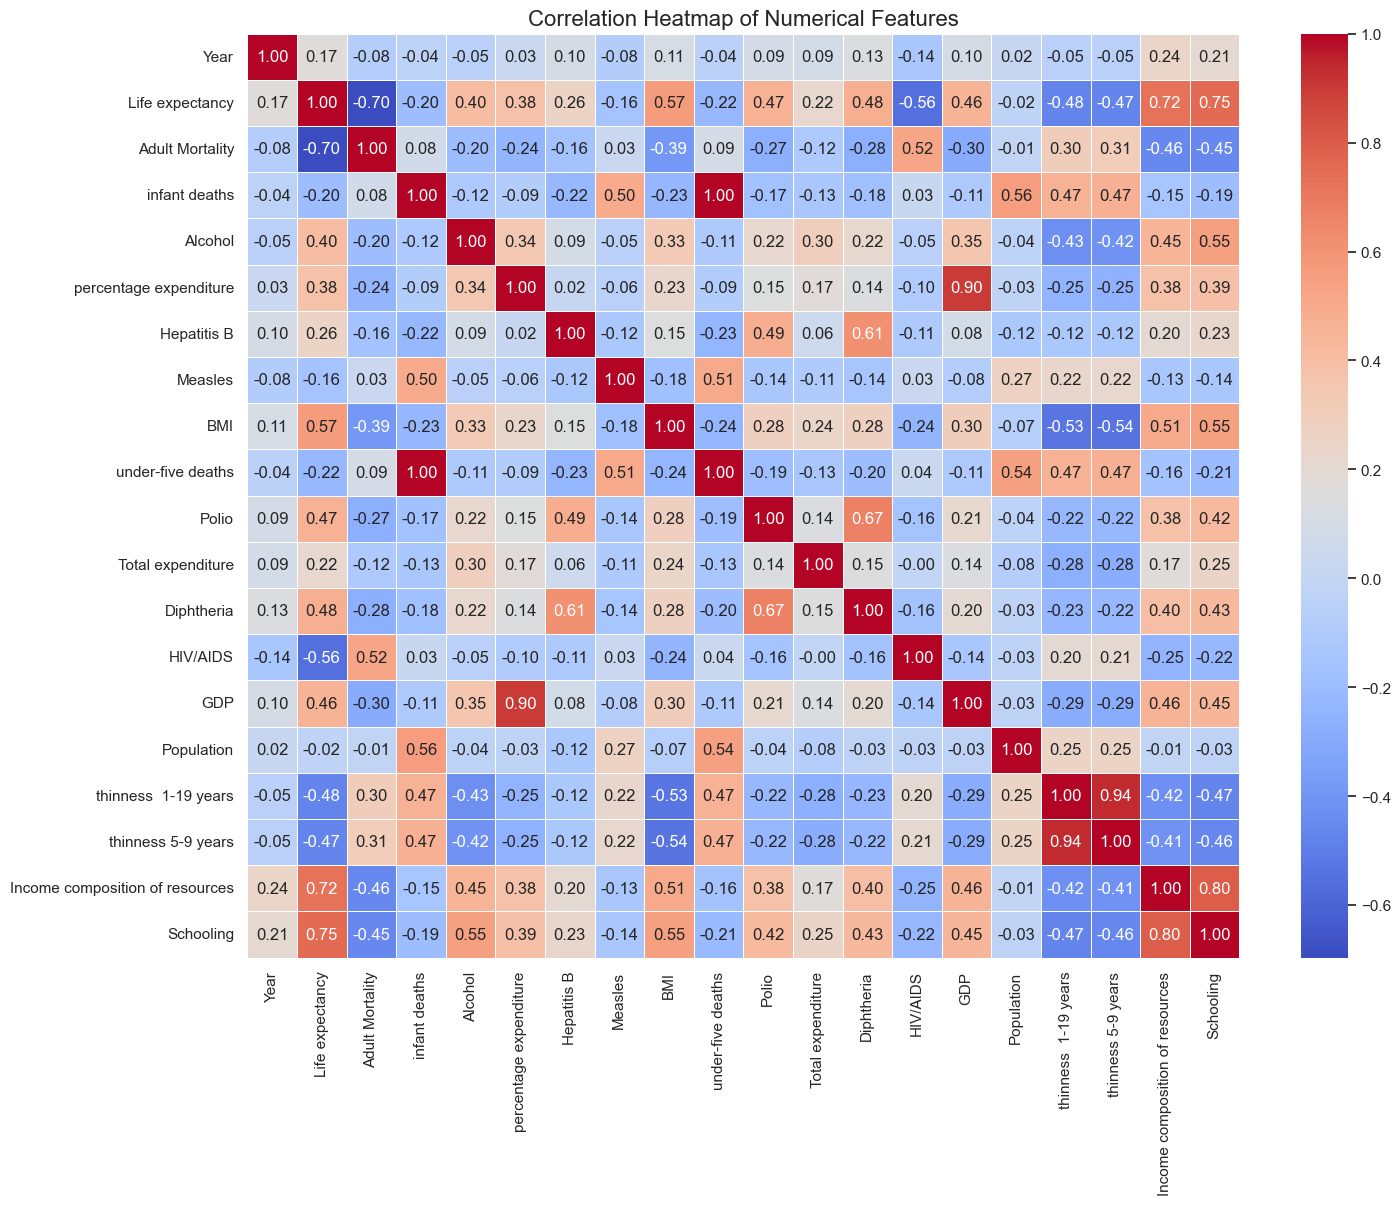

Tương quan với Life expectancy:
Life expectancy                    1.000000
Schooling                          0.751975
Income composition of resources    0.724776
BMI                                0.567694
Diphtheria                         0.479495
Polio                              0.465556
GDP                                0.461455
Alcohol                            0.404877
percentage expenditure             0.381864
Hepatitis B                        0.256762
Total expenditure                  0.218086
Year                               0.170033
Population                        -0.021538
Measles                           -0.157586
infant deaths                     -0.196557
under-five deaths                 -0.222529
thinness 5-9 years                -0.471584
thinness  1-19 years              -0.477183
HIV/AIDS                          -0.556556
Adult Mortality                   -0.696359
Name: Life expectancy, dtype: float64


In [6]:
plt.figure(figsize=(16, 12))
# Tính ma trận tương quan (chỉ tính trên các biến numeric)
corr_matrix = df[numeric_cols].corr()

# Vẽ heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features', fontsize=16)
plt.show()

# Xem tương quan cụ thể với biến mục tiêu (Life expectancy)
print("Tương quan với Life expectancy:")
print(corr_matrix['Life expectancy'].sort_values(ascending=False))

### Nhận xét về Ma trận tương quan (Correlation)
Từ Heatmap, ta đánh giá được tiềm năng của các biến dự báo và nguy cơ đa cộng tuyến:
* **Các biến tương quan tốt với biến mục tiêu:** `Schooling` (0.75) và `Income composition of resources` (0.72) có tương quan thuận rất mạnh với tuổi thọ. Ngược lại, `Adult Mortality` (-0.70) và `HIV/AIDS` (-0.56) có tương quan nghịch mạnh. Đây sẽ là những biến chủ chốt (predictors) đóng góp lớn vào mô hình hồi quy.
* **Cảnh báo Hiện tượng Đa cộng tuyến (Multicollinearity):** * Cặp biến `infant deaths` và `under-five deaths` có hệ số tương quan gần như tuyệt đối ($r \approx 0.99$).
    * Cặp biến `GDP` và `percentage expenditure` cũng có tương quan rất cao ($r = 0.90$).
* **Hành động:** Đa cộng tuyến cao làm ma trận $(X^TX)$ gần như suy biến, khiến sai số chuẩn (Standard Error) của các hệ số hồi quy $\hat{\beta}$ tăng vọt và làm mất tính ổn định của mô hình OLS. Nhóm sẽ phải **loại bỏ một trong hai biến** của các cặp đa cộng tuyến này, hoặc sử dụng các mô hình có cơ chế điều chuẩn như **Ridge/Lasso** ở giai đoạn sau.

## 4. Phân tích Missing Values

,Missing Values,Percentage (%)
Population,652,22.191967
Hepatitis B,553,18.822328
GDP,448,15.248468
Total expenditure,226,7.692308
Alcohol,194,6.603131
Income composition of resources,167,5.684139
Schooling,163,5.547992
thinness 5-9 years,34,1.157250
thinness 1-19 years,34,1.157250
BMI,34,1.157250


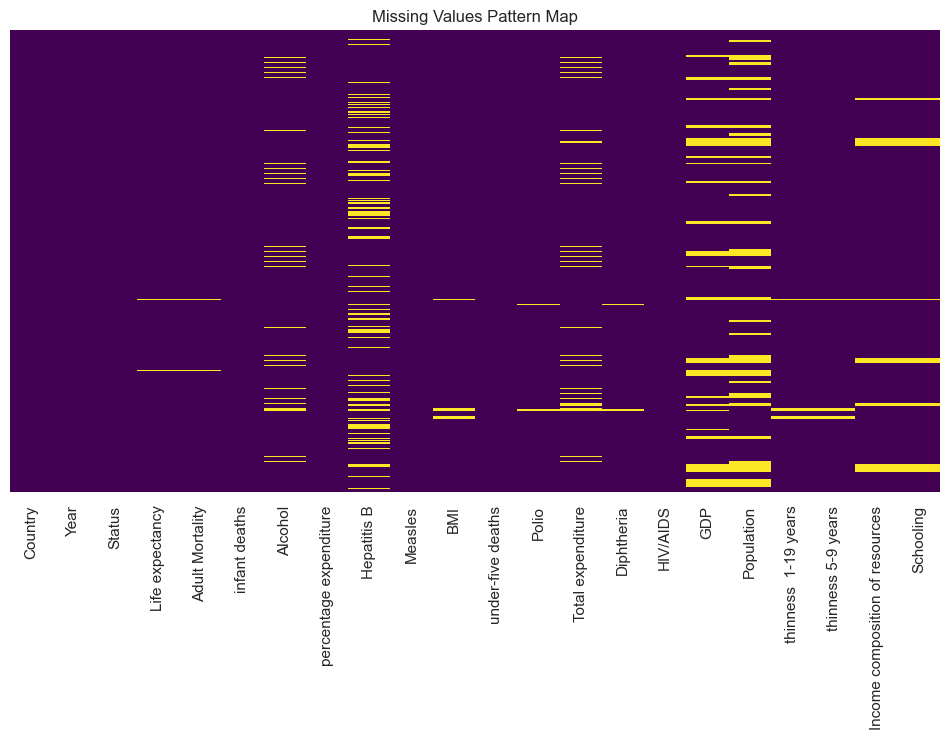

In [7]:
# Tính số lượng và tỉ lệ missing values
missing_data = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Percentage (%)': (df.isnull().sum() / len(df)) * 100
})
missing_data = missing_data[missing_data['Missing Values'] > 0].sort_values(by='Percentage (%)', ascending=False)

display(missing_data)

# Trực quan hóa vị trí missing values để phán đoán cơ chế
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Missing Values Pattern Map')
plt.show()

### Nhận xét về Dữ liệu khuyết (Missing Data)
Phân tích bảng thống kê và Missing Pattern Map cho thấy:
* **Tỉ lệ khuyết:** Khá cao ở các biến quan trọng như `Population` (22.2%), `Hepatitis B` (18.8%), và `GDP` (15.2%).
* **Cơ chế thiếu hụt:** Dữ liệu không bị khuyết một cách ngẫu nhiên hoàn toàn. Sự thiếu hụt thường đi theo từng dải (đại diện cho các quốc gia đang/kém phát triển không có đủ hệ thống thu thập dữ liệu y tế/nhân khẩu học ổn định qua các năm). Đây là biểu hiện của cơ chế **MAR (Missing At Random)** hoặc có phần thiên về MNAR.
* **Hướng xử lý:** Với cơ chế này và tỉ lệ khuyết lớn hơn 15%, việc điền khuyết bằng Mean/Median (Simple Imputation) sẽ làm giảm phương sai tự nhiên của dữ liệu và bóp méo mối quan hệ tuyến tính. Nhóm đề xuất sử dụng các phương pháp nội suy nâng cao như **K-Nearest Neighbors Imputer (KNNImputer)** hoặc **Regression Imputation (IterativeImputer)** trong module DataPipeline để giữ nguyên tính toàn vẹn của tập dữ liệu.